## 1. Imports and Dependencies

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, spearmanr
from scipy import stats
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ──────────────────────────────────────────────────────────
BLUE        = '#1565C0'   # primary — subscribed / positive
ORANGE      = '#E64A19'   # secondary — not subscribed / negative
RED         = '#C62828'   # reference lines / alerts
GREEN       = '#2E7D32'   # positive highlights
TEAL        = '#00695C'   # economic / neutral positive
PURPLE      = '#6A1B9A'   # prior-engagement accent
AMBER       = '#F57F17'   # warning / caution
GREY        = '#78909C'   # background / below-baseline
LIGHT_BLUE  = '#BBDEFB'
LIGHT_GREEN = '#C8E6C9'

PALETTE = {'yes': BLUE, 'no': ORANGE}

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'savefig.dpi'       : 150,
    'font.family'       : 'sans-serif',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 10,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#FAFAFA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'axes.edgecolor'    : '#CCCCCC',
})

def save_fig(name):
    plt.savefig(f'fig_{name}.png', bbox_inches='tight')
    print(f'  Saved: fig_{name}.png')


---
## 2. Data Loading

In [13]:
# ── Load & clean dataset ────────────────────────────────────────────────────
import pandas as pd
from io import StringIO

file_path = r"/Users/yash/Documents/Uni Assignments/CODE files/Stats/TeleCom_Data-1.csv"

# Read file and remove quotes
with open(file_path, 'r', encoding='utf-8') as f:
    content = f.read().replace('"', '')

# Load into DataFrame
df = pd.read_csv(StringIO(content), sep=';')

# Clean column names
df.columns = df.columns.str.strip()

# Rename target column if present
if 'y' in df.columns:
    df.rename(columns={'y': 'subscribed'}, inplace=True)

# Output
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

df.head()

Dataset loaded: 41,180 rows × 21 columns
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


---
## 3. Data Inspection, Cleaning & Preprocessing

### 3.1 Basic Inspection

In [8]:
print('── Shape ──────────────────────────────')
print(f'  Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

print('\n── Data Types ─────────────────────────')
print(df.dtypes.to_string())

print('\n── Null Values ────────────────────────')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else '  No null values found.')

print('\n── Duplicate Rows ─────────────────────')
print(f'  {df.duplicated().sum()} duplicate rows')

── Shape ──────────────────────────────
  Rows: 41,180   Columns: 21

── Data Types ─────────────────────────
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
subscribed            str

── Null Values ────────────────────────
  No null values found.

── Duplicate Rows ─────────────────────
  12 duplicate rows


In [14]:
# ── Coded unknowns audit ─────────────────────────────────────────────────────
unknown_counts = (df == 'unknown').sum()
unknown_pct    = (unknown_counts / len(df) * 100).round(2)
quality_df     = pd.DataFrame({'Unknown Count': unknown_counts, 'Unknown %': unknown_pct})
quality_df     = quality_df[quality_df['Unknown Count'] > 0].sort_values('Unknown %', ascending=False)

print('── Coded Unknowns per Feature ─────────')
print(quality_df.to_string())

── Coded Unknowns per Feature ─────────
           Unknown Count  Unknown %
default             8596      20.87
education           1731       4.20
housing              990       2.40
loan                 990       2.40
job                  330       0.80
marital               80       0.19


### 3.2 Preprocessing Summary

| Issue | Detail | Action |
|---|---|---|
| True missing values | None detected | No imputation needed |
| Coded unknowns | `default` 20.9%, `education` 4.2%, `job` 0.8%, `marital` 0.2% | Retained as separate category |
| Duplicate rows | Negligible | No action |
| `pdays = 999` | Sentinel for "no prior contact" — 96.3% of records | Binary-encode before modelling |
| Class imbalance | 88.7% No vs 11.3% Yes | SMOTE or class weighting required for ML |

In [16]:
# ── Feature engineering for EDA ──────────────────────────────────────────────
df_enc = df.copy()
df_enc['subscribed_bin'] = df_enc['subscribed'].eq('yes').astype(int)
df_enc['previously_contacted'] = (df_enc['pdays'] != 999).astype(int)
df_enc['age_group'] = pd.cut(
    df_enc['age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18–25', '26–35', '36–45', '46–55', '56–65', '66+']
)
df_enc['campaign_bin'] = pd.cut(
    df_enc['campaign'],
    bins=[0, 1, 2, 3, 5, 10, 60],
    labels=['1', '2', '3', '4–5', '6–10', '10+']
)

numeric_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols     = [c for c in df.select_dtypes(include='object').columns if c != 'subscribed']
overall_rate = df['subscribed'].eq('yes').mean() * 100

print(f'Preprocessing complete.')
print(f'Overall subscription rate: {overall_rate:.1f}%')

Preprocessing complete.
Overall subscription rate: 11.3%


### 3.3 Target Variable Distribution

  Saved: fig_00_target_distribution.png


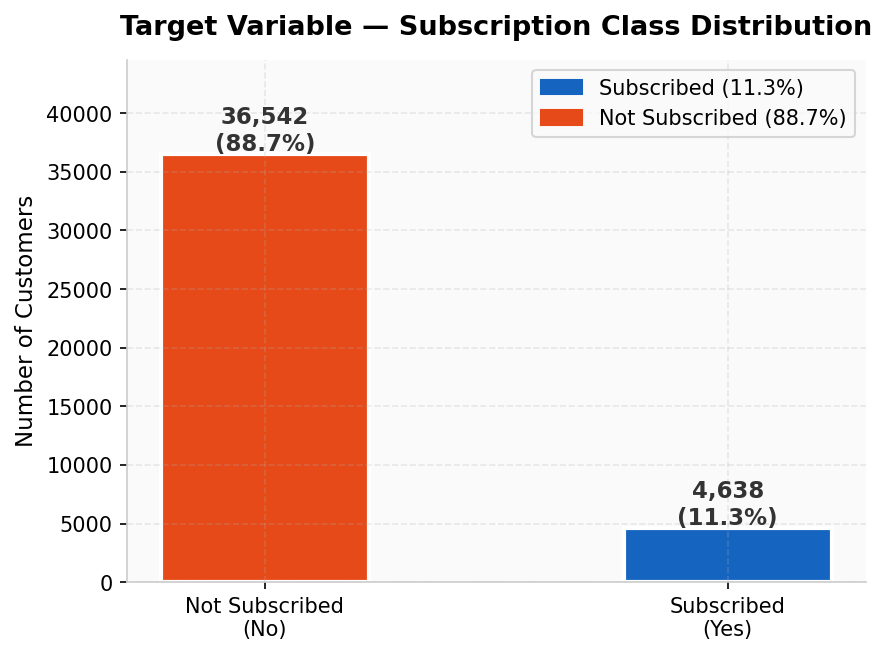

In [17]:
# Figure 0: Class distribution — single clean bar chart
target_counts = df['subscribed'].value_counts()
target_pct    = df['subscribed'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4.5))

bars = ax.bar(
    ['Not Subscribed\n(No)', 'Subscribed\n(Yes)'],
    target_counts.values,
    color=[ORANGE, BLUE],
    edgecolor='white', linewidth=2, width=0.45
)

for bar, (v, p) in zip(bars, zip(target_counts.values, target_pct.values)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold',
            color='#333333')

ax.set_ylabel('Number of Customers')
ax.set_ylim(0, target_counts.max() * 1.22)
ax.set_title('Target Variable — Subscription Class Distribution',
             fontweight='bold', pad=12)

no_patch  = mpatches.Patch(color=ORANGE, label='Not Subscribed (88.7%)')
yes_patch = mpatches.Patch(color=BLUE,   label='Subscribed (11.3%)')
ax.legend(handles=[yes_patch, no_patch], loc='upper right')

plt.tight_layout()
save_fig('00_target_distribution')
plt.show()

---
## 4. Exploratory Data Analysis

The EDA is structured around four research questions. 

---
### RQ1 — What demographic and socioeconomic characteristics are most strongly associated with subscription?

  Saved: fig_rq1_fig1_job_subscription_rate.png


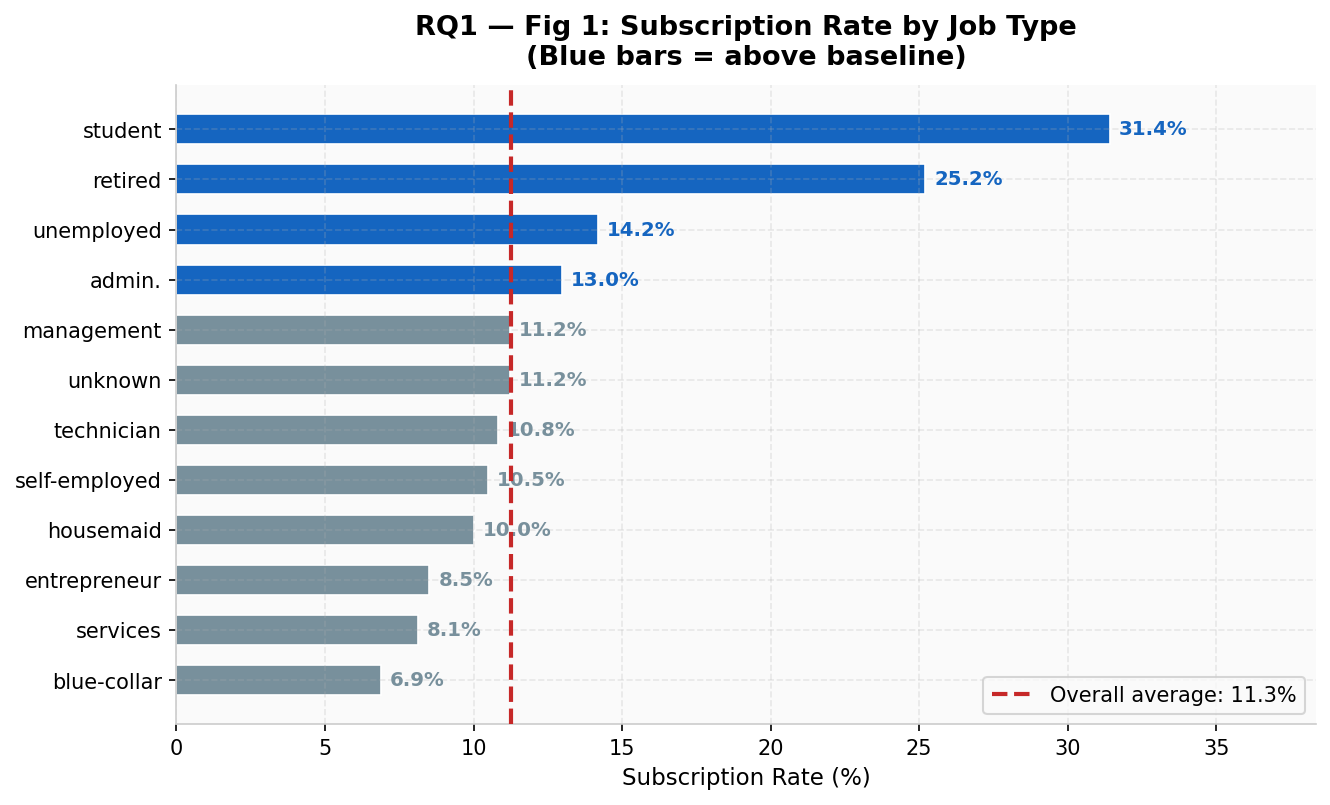

In [19]:
# ── Figure 1a: Subscription rate by Job Type ─────────────────────────────────
job_rates = (
    df.groupby('job')['subscribed']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .sort_values(ascending=True)
)

colors_job = [BLUE if r > overall_rate else GREY for r in job_rates.values]

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(job_rates.index, job_rates.values,
               color=colors_job, edgecolor='white', linewidth=0.8, height=0.6)

ax.axvline(overall_rate, color=RED, linestyle='--', linewidth=2,
           label=f'Overall average: {overall_rate:.1f}%', zorder=5)

for bar, val in zip(bars, job_rates.values):
    color = BLUE if val > overall_rate else GREY
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9.5,
            color=color, fontweight='bold')

ax.set_xlabel('Subscription Rate (%)')
ax.set_title('RQ1 — Fig 1: Subscription Rate by Job Type\n'
             '(Blue bars = above baseline)', fontweight='bold', pad=10)
ax.set_xlim(0, job_rates.max() * 1.22)
ax.legend()

plt.tight_layout()
save_fig('rq1_fig1_job_subscription_rate')
plt.show()

  Saved: fig_rq1_fig2_education_age.png


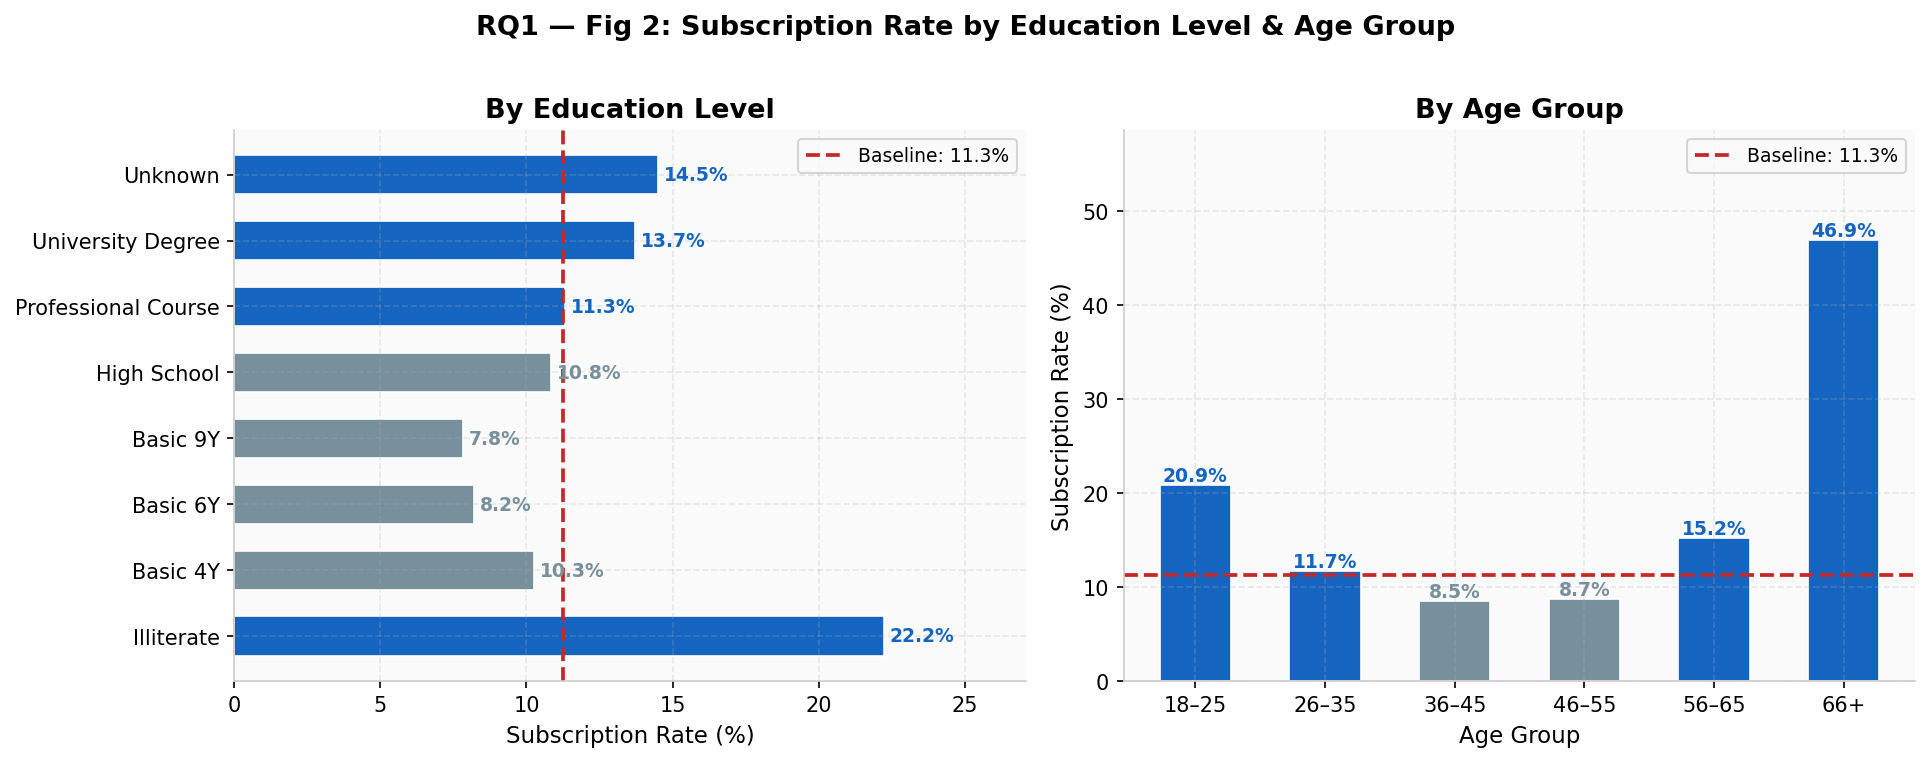

In [20]:
# ── Figure 1b: Subscription rate by Education & Age Group (grouped bar) ───────
edu_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
             'high.school', 'professional.course', 'university.degree', 'unknown']

edu_rates = (
    df.groupby('education')['subscribed']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .reindex([e for e in edu_order if e in df['education'].unique()])
)

age_rates = (
    df_enc.groupby('age_group', observed=True)['subscribed_bin']
          .mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Education panel
colors_edu = [BLUE if r > overall_rate else GREY for r in edu_rates.values]
axes[0].barh(
    [e.replace('.', ' ').title() for e in edu_rates.index],
    edu_rates.values,
    color=colors_edu, edgecolor='white', linewidth=0.8, height=0.6
)
axes[0].axvline(overall_rate, color=RED, linestyle='--', linewidth=1.8,
                label=f'Baseline: {overall_rate:.1f}%')
for i, v in enumerate(edu_rates.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9,
                 color=BLUE if v > overall_rate else GREY, fontweight='bold')
axes[0].set_xlabel('Subscription Rate (%)')
axes[0].set_title('By Education Level', fontweight='bold')
axes[0].set_xlim(0, edu_rates.max() * 1.22)
axes[0].legend(fontsize=9)

# Age group panel
colors_age = [BLUE if r > overall_rate else GREY for r in age_rates.values]
bars_age = axes[1].bar(
    age_rates.index.astype(str), age_rates.values,
    color=colors_age, edgecolor='white', linewidth=0.8, width=0.55
)
axes[1].axhline(overall_rate, color=RED, linestyle='--', linewidth=1.8,
                label=f'Baseline: {overall_rate:.1f}%')
for bar, val in zip(bars_age, age_rates.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=9,
                 color=BLUE if val > overall_rate else GREY, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_title('By Age Group', fontweight='bold')
axes[1].set_ylim(0, age_rates.max() * 1.25)
axes[1].legend(fontsize=9)

fig.suptitle('RQ1 — Fig 2: Subscription Rate by Education Level & Age Group',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('rq1_fig2_education_age')
plt.show()

**RQ1 Key Findings:**
- **Students (31.4%)** and **retired customers (25.2%)** convert well above the 11.3% baseline — likely due to flexible schedules and financial planning motivations.
- **University-degree holders** outperform other education levels; illiterate and basic-education groups convert below average.
- **Customers aged 18–25 and 56–65** show the highest subscription rates; the 36–45 mid-career segment has the lowest.

---
### RQ2 — How do contact timing and contact frequency affect subscription likelihood?

  Saved: fig_rq2_fig3_month_dow.png


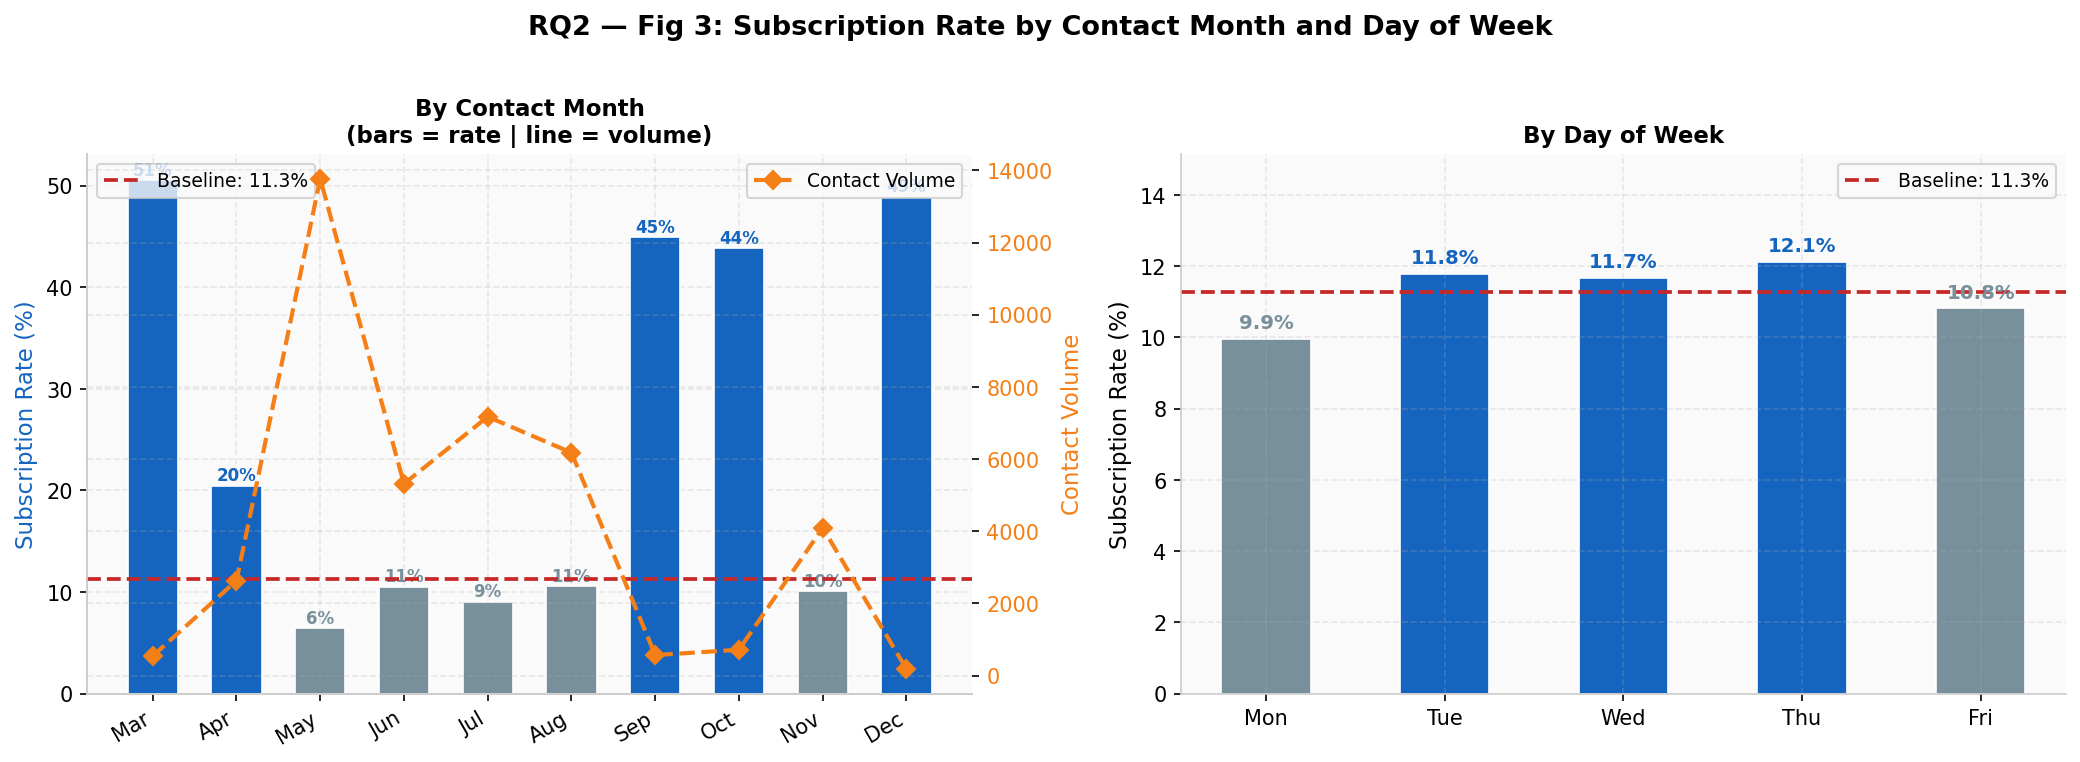

In [22]:
# ── Figure 2a: Subscription rate by Month & Day of Week (side by side) ────────
month_order  = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
dow_order    = ['mon','tue','wed','thu','fri']
dow_labels   = ['Mon','Tue','Wed','Thu','Fri']

month_rates = (
    df.groupby('month')['subscribed']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .reindex([m for m in month_order if m in df['month'].unique()])
)
month_vol = df.groupby('month').size().reindex(month_rates.index)

dow_rates = (
    df.groupby('day_of_week')['subscribed']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .reindex([d for d in dow_order if d in df['day_of_week'].unique()])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Month panel — dual axis (rate + volume)
ax1 = axes[0]
ax2 = ax1.twinx()

colors_m = [BLUE if r > overall_rate else GREY for r in month_rates.values]
ax1.bar(range(len(month_rates)), month_rates.values,
        color=colors_m, edgecolor='white', linewidth=0.8, width=0.6, zorder=3)
ax2.plot(range(len(month_rates)), month_vol.values,
         color=AMBER, marker='D', linewidth=2, markersize=6,
         linestyle='--', label='Contact Volume', zorder=4)

ax1.axhline(overall_rate, color=RED, linestyle='--', linewidth=1.8,
            label=f'Baseline: {overall_rate:.1f}%', zorder=5)
ax1.set_xticks(range(len(month_rates)))
ax1.set_xticklabels([month_labels[month_order.index(m)] for m in month_rates.index],
                    rotation=30, ha='right')
ax1.set_ylabel('Subscription Rate (%)', color=BLUE)
ax2.set_ylabel('Contact Volume', color=AMBER)
ax2.tick_params(axis='y', labelcolor=AMBER)
ax1.set_title('By Contact Month\n(bars = rate | line = volume)',
              fontweight='bold', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

for i, val in enumerate(month_rates.values):
    ax1.text(i, val + 0.5, f'{val:.0f}%', ha='center', fontsize=8,
             color=BLUE if val > overall_rate else GREY, fontweight='bold')

# Day of week panel
colors_d = [BLUE if r > overall_rate else GREY for r in dow_rates.values]
bars_d = axes[1].bar(
    [dow_labels[dow_order.index(d)] for d in dow_rates.index],
    dow_rates.values,
    color=colors_d, edgecolor='white', linewidth=0.8, width=0.5
)
axes[1].axhline(overall_rate, color=RED, linestyle='--', linewidth=1.8,
                label=f'Baseline: {overall_rate:.1f}%')
for bar, val in zip(bars_d, dow_rates.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9.5,
                 color=BLUE if val > overall_rate else GREY, fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_title('By Day of Week', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, dow_rates.max() * 1.25)
axes[1].legend(fontsize=9)

fig.suptitle('RQ2 — Fig 3: Subscription Rate by Contact Month and Day of Week',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('rq2_fig3_month_dow')
plt.show()

  Saved: fig_rq2_fig4_diminishing_returns.png


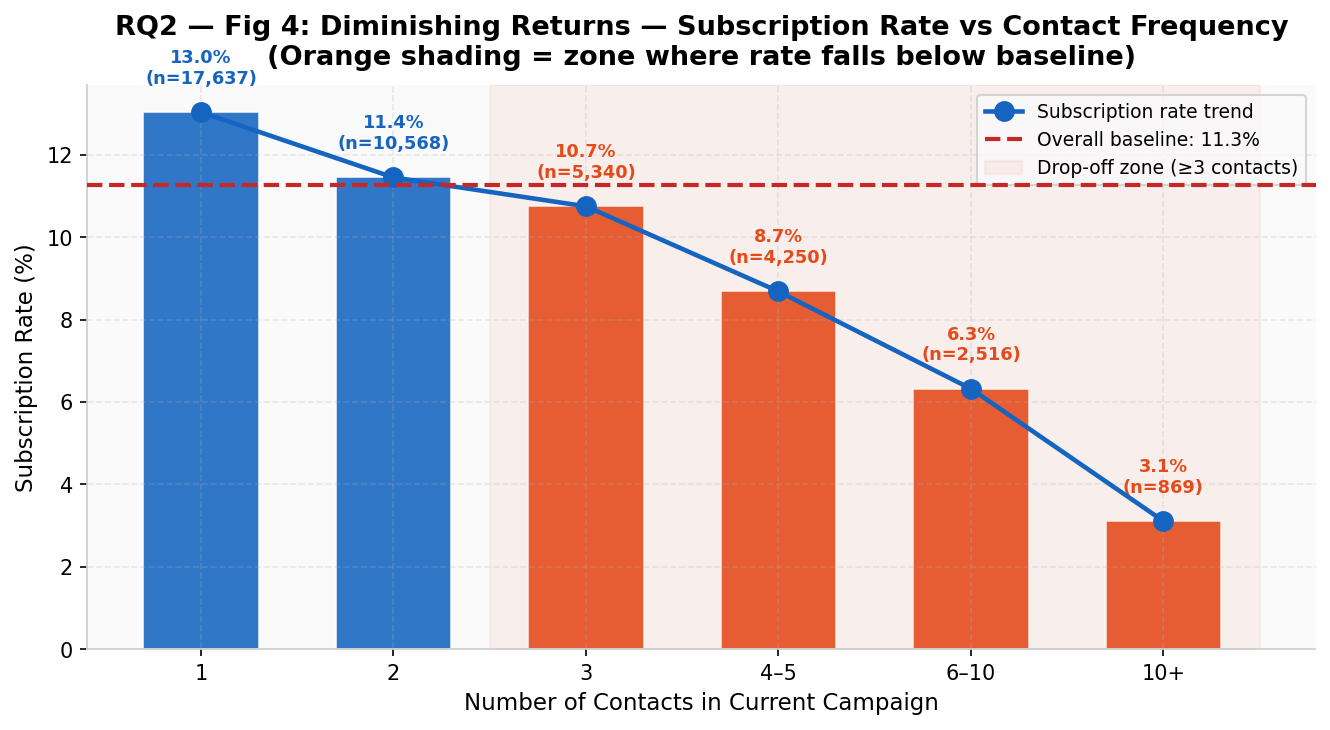

In [23]:
# ── Figure 2b: Diminishing returns — contacts vs subscription rate ────────────
camp_rates = df_enc.groupby('campaign_bin', observed=True)['subscribed_bin'].mean() * 100
camp_counts = df_enc.groupby('campaign_bin', observed=True).size()

fig, ax = plt.subplots(figsize=(9, 5))

colors_c = [BLUE if r > overall_rate else ORANGE for r in camp_rates.values]
bars_c = ax.bar(
    range(len(camp_rates)), camp_rates.values,
    color=colors_c, edgecolor='white', linewidth=0.8, width=0.6, alpha=0.88
)

ax.plot(range(len(camp_rates)), camp_rates.values,
        color=BLUE, marker='o', linewidth=2.2, markersize=9,
        zorder=5, label='Subscription rate trend')

ax.axhline(overall_rate, color=RED, linestyle='--', linewidth=2,
           label=f'Overall baseline: {overall_rate:.1f}%', zorder=6)

# Annotate the inflection point
ax.axvspan(1.5, 5.5, color=ORANGE, alpha=0.06, label='Drop-off zone (≥3 contacts)')

ax.set_xticks(range(len(camp_rates)))
ax.set_xticklabels(camp_rates.index.astype(str))
ax.set_xlabel('Number of Contacts in Current Campaign')
ax.set_ylabel('Subscription Rate (%)')
ax.set_title('RQ2 — Fig 4: Diminishing Returns — Subscription Rate vs Contact Frequency\n'
             '(Orange shading = zone where rate falls below baseline)',
             fontweight='bold', pad=10)
ax.legend(fontsize=9)

for i, (val, n) in enumerate(zip(camp_rates.values, camp_counts.values)):
    ax.text(i, val + 0.7, f'{val:.1f}%\n(n={n:,})',
            ha='center', fontsize=8.5, fontweight='bold',
            color=BLUE if val > overall_rate else ORANGE)

plt.tight_layout()
save_fig('rq2_fig4_diminishing_returns')
plt.show()

**RQ2 Key Findings:**
- **March, September, and October** deliver the highest subscription rates, well above the 11.3% baseline. **May** has the highest call volume but performs below average — a classic over-saturation effect.
- **Thursday and Tuesday** show marginally higher conversion; Friday is the weakest day.
- Subscription rate **drops sharply after 2 contacts**. Customers contacted 6+ times convert at just ~3% — active harm to conversion.

---
### RQ3 — To what extent does a customer's prior campaign history predict current subscription?

  Saved: fig_rq3_fig5_prior_engagement.png


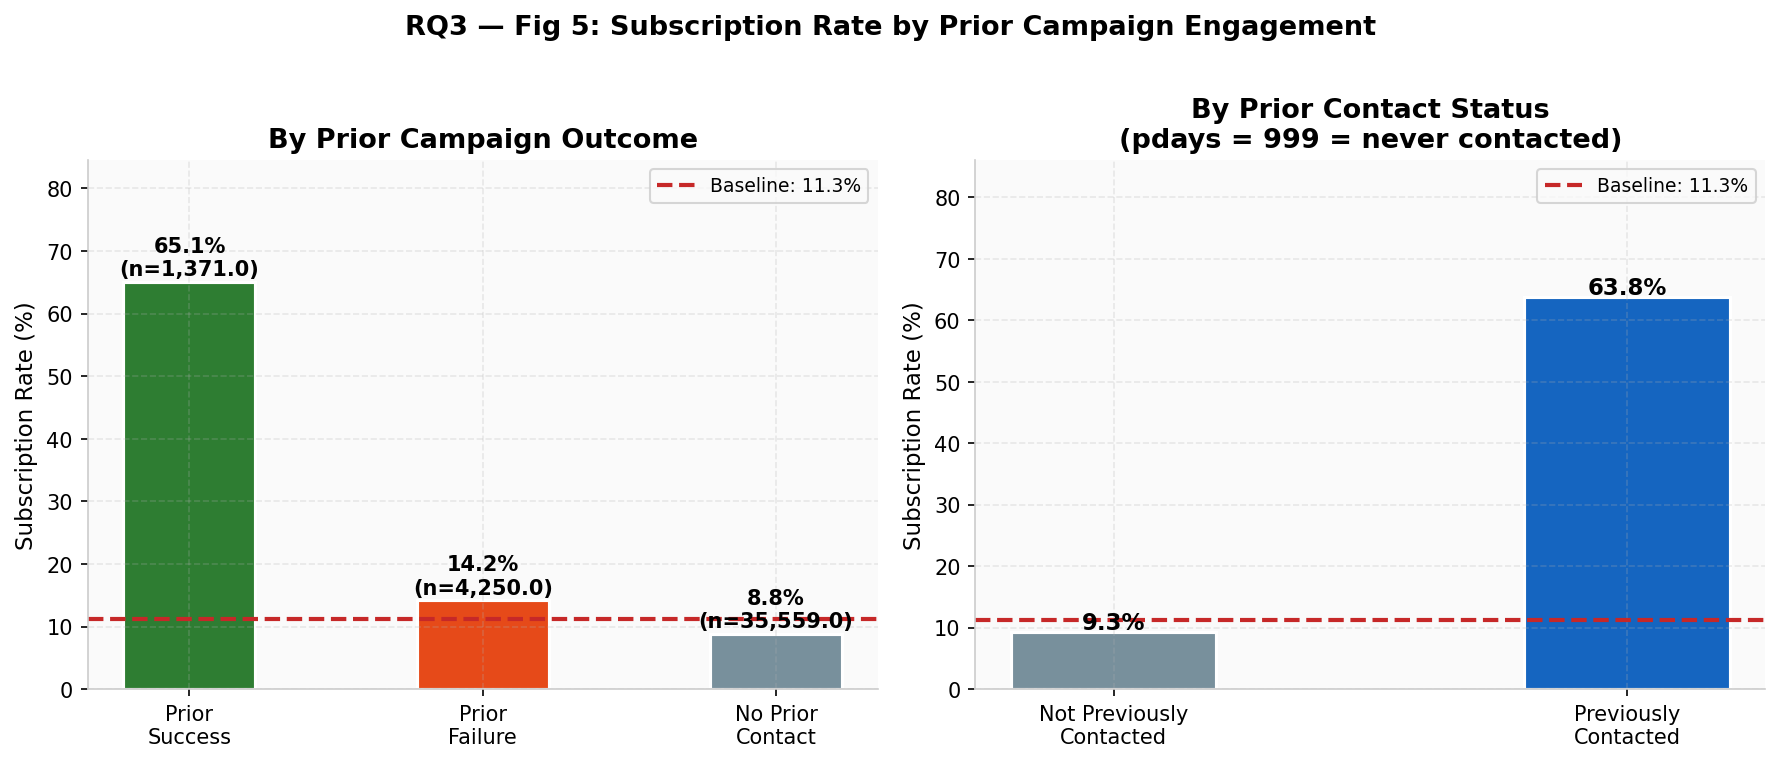

In [24]:
# ── Figure 3a: Subscription rate by Prior Outcome & Prior Contact Status ──────
pout_rates = (
    df_enc.groupby('poutcome')['subscribed_bin']
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'rate', 'count': 'n'})
)
pout_rates['rate_%'] = (pout_rates['rate'] * 100).round(2)
pout_rates = pout_rates.sort_values('rate_%', ascending=False)

pout_label_map  = {'success': 'Prior\nSuccess', 'failure': 'Prior\nFailure',
                   'nonexistent': 'No Prior\nContact'}
pout_color_map  = {'success': GREEN, 'failure': ORANGE, 'nonexistent': GREY}

contact_rate = df_enc.groupby(
    df_enc['pdays'].eq(999).map({True: 'Not Previously\nContacted',
                                 False: 'Previously\nContacted'})
)['subscribed_bin'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Prior outcome
labels_po = [pout_label_map.get(x, x) for x in pout_rates.index]
colors_po = [pout_color_map.get(x, GREY) for x in pout_rates.index]

bars_po = axes[0].bar(labels_po, pout_rates['rate_%'],
                      color=colors_po, edgecolor='white', linewidth=1.5, width=0.45)
axes[0].axhline(overall_rate, color=RED, linestyle='--', linewidth=2,
                label=f'Baseline: {overall_rate:.1f}%')
for bar, (_, row) in zip(bars_po, pout_rates.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{row['rate_%']:.1f}%\n(n={row['n']:,})",
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].set_title('By Prior Campaign Outcome', fontweight='bold')
axes[0].set_ylim(0, pout_rates['rate_%'].max() * 1.3)
axes[0].legend(fontsize=9)

# Prior contact status
colors_cs = [BLUE if v > overall_rate else GREY for v in contact_rate.values]
bars_cs = axes[1].bar(contact_rate.index, contact_rate.values,
                      color=colors_cs, edgecolor='white', linewidth=1.5, width=0.4)
axes[1].axhline(overall_rate, color=RED, linestyle='--', linewidth=2,
                label=f'Baseline: {overall_rate:.1f}%')
for bar, val in zip(bars_cs, contact_rate.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_title('By Prior Contact Status\n(pdays = 999 = never contacted)',
                  fontweight='bold')
axes[1].set_ylim(0, contact_rate.max() * 1.35)
axes[1].legend(fontsize=9)

fig.suptitle('RQ3 — Fig 5: Subscription Rate by Prior Campaign Engagement',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('rq3_fig5_prior_engagement')
plt.show()

  Saved: fig_rq3_fig6_previous_contacts.png


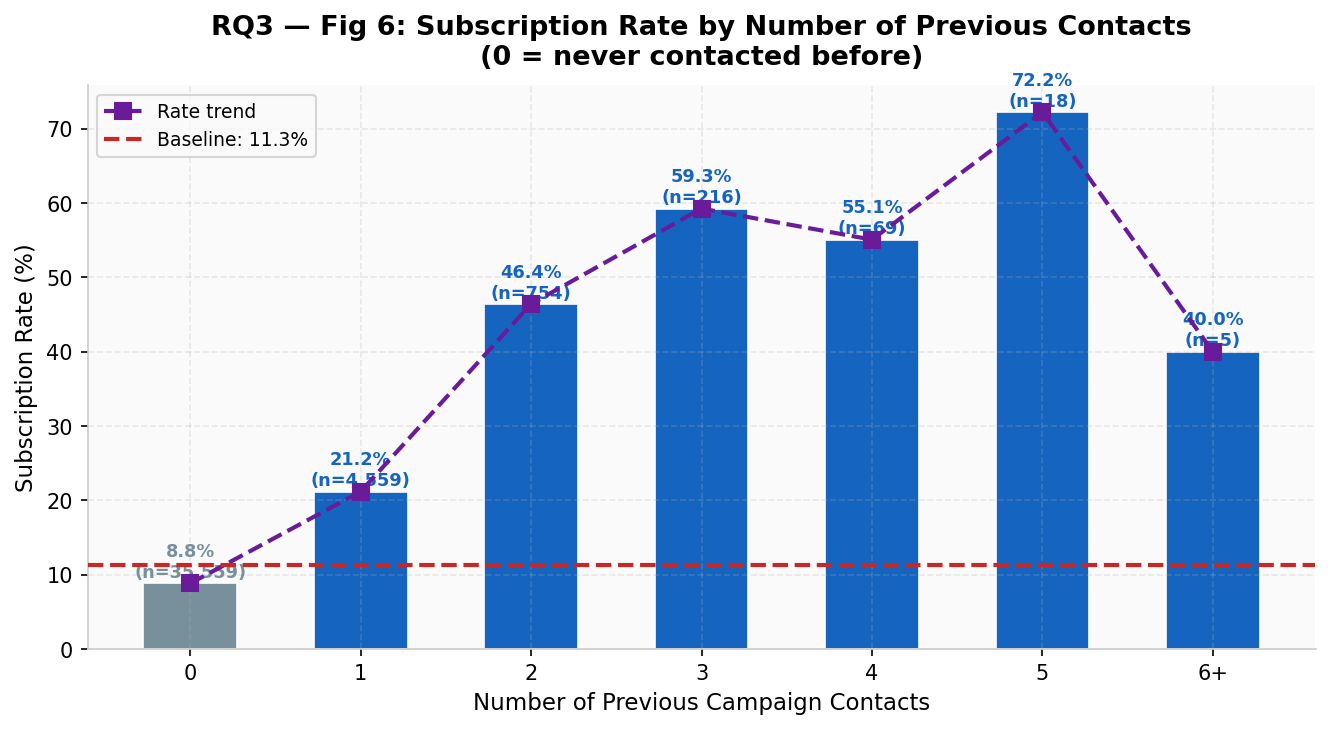

In [25]:
# ── Figure 3b: Number of previous contacts vs subscription rate ───────────────
prev_rates = (
    df_enc.groupby('previous')['subscribed_bin']
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'rate', 'count': 'n'})
)
prev_rates['rate_%'] = prev_rates['rate'] * 100

# Group 5+ together to avoid noise
prev_display = prev_rates[prev_rates.index <= 5].copy()
if prev_rates.index.max() > 5:
    overflow = prev_rates[prev_rates.index > 5]
    combined_rate = (overflow['rate'] * overflow['n']).sum() / overflow['n'].sum() * 100
    combined_n    = overflow['n'].sum()
    prev_display.loc[6] = [combined_rate / 100, combined_n, combined_rate]

fig, ax = plt.subplots(figsize=(9, 5))

colors_p = [BLUE if r > overall_rate else GREY for r in prev_display['rate_%']]
bars_p = ax.bar(
    prev_display.index.astype(str).tolist()[:-1] + ['6+'],
    prev_display['rate_%'],
    color=colors_p, edgecolor='white', linewidth=0.8, width=0.55
)
ax.plot(range(len(prev_display)), prev_display['rate_%'],
        color=PURPLE, marker='s', linewidth=2, markersize=8,
        linestyle='--', zorder=5, label='Rate trend')
ax.axhline(overall_rate, color=RED, linestyle='--', linewidth=2,
           label=f'Baseline: {overall_rate:.1f}%', zorder=6)

ax.set_xlabel('Number of Previous Campaign Contacts')
ax.set_ylabel('Subscription Rate (%)')
ax.set_title('RQ3 — Fig 6: Subscription Rate by Number of Previous Contacts\n'
             '(0 = never contacted before)', fontweight='bold', pad=10)
ax.legend(fontsize=9)

for i, (val, n) in enumerate(zip(prev_display['rate_%'], prev_display['n'])):
    ax.text(i, val + 0.8, f'{val:.1f}%\n(n={int(n):,})',
            ha='center', fontsize=8.5, fontweight='bold',
            color=BLUE if val > overall_rate else GREY)

plt.tight_layout()
save_fig('rq3_fig6_previous_contacts')
plt.show()

**RQ3 Key Findings:**
- **Prior successful outcome** is the single strongest predictor: 65.1% conversion — **5.7× the baseline**. Prioritising this group for re-contact is the highest-ROI action available.
- Customers with **any prior contact** (pdays ≠ 999) convert at roughly double the rate of those who have never been contacted.
- Having 1–3 previous contacts is associated with higher subscription; beyond that, returns diminish rapidly.

---
### RQ4 — Do macroeconomic conditions moderate subscription likelihood?

  Saved: fig_rq4_fig7_economic_violins.png


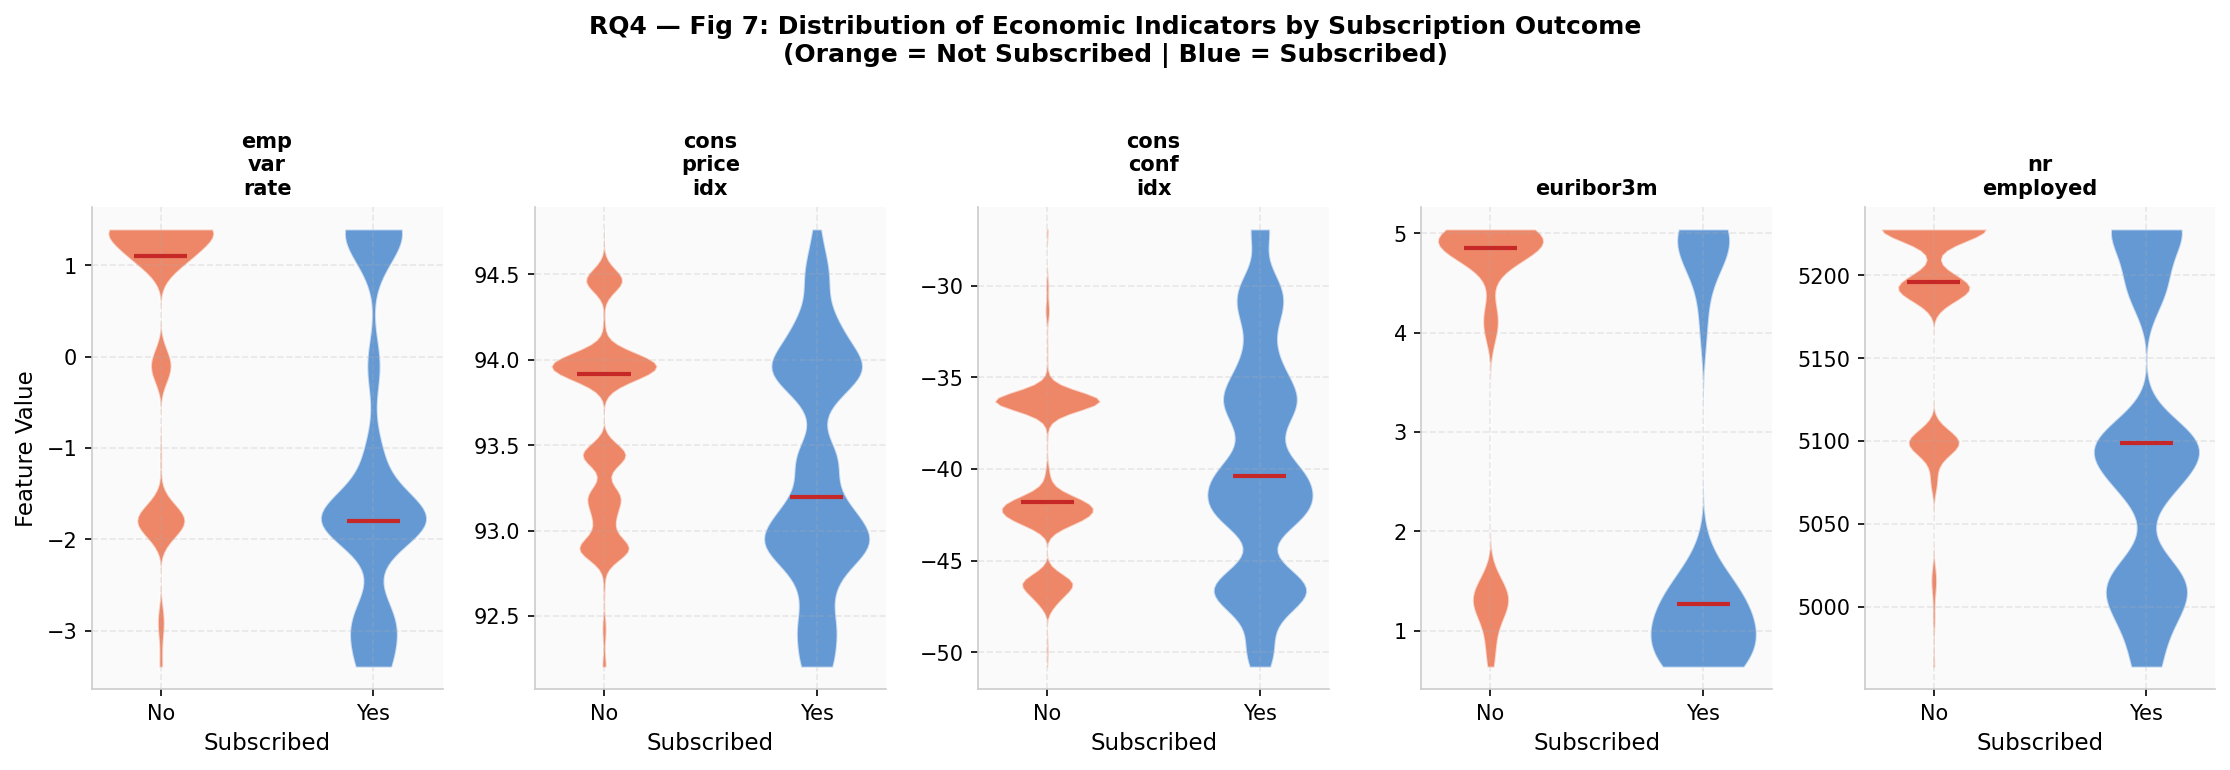

In [27]:
# ── Figure 4a: Economic indicators — violin plots by subscription outcome ─────
fig, axes = plt.subplots(1, len(econ_cols), figsize=(15, 5), sharey=False)

for ax, col in zip(axes, econ_cols):
    data_yes = df_enc.loc[df_enc['subscribed_bin'] == 1, col].dropna()
    data_no  = df_enc.loc[df_enc['subscribed_bin'] == 0, col].dropna()

    parts = ax.violinplot([data_no, data_yes], positions=[0, 1],
                          showmedians=True, showextrema=False)

    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(ORANGE if i == 0 else BLUE)
        pc.set_alpha(0.65)
        pc.set_edgecolor('white')
    parts['cmedians'].set_color(RED)
    parts['cmedians'].set_linewidth(2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No', 'Yes'], fontsize=10)
    ax.set_title(col.replace('.', '\n'), fontsize=10, fontweight='bold')
    ax.set_xlabel('Subscribed')

axes[0].set_ylabel('Feature Value')

fig.suptitle('RQ4 — Fig 7: Distribution of Economic Indicators by Subscription Outcome\n'
             '(Orange = Not Subscribed | Blue = Subscribed)',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
save_fig('rq4_fig7_economic_violins')
plt.show()

  Saved: fig_rq4_fig8_economic_bands.png


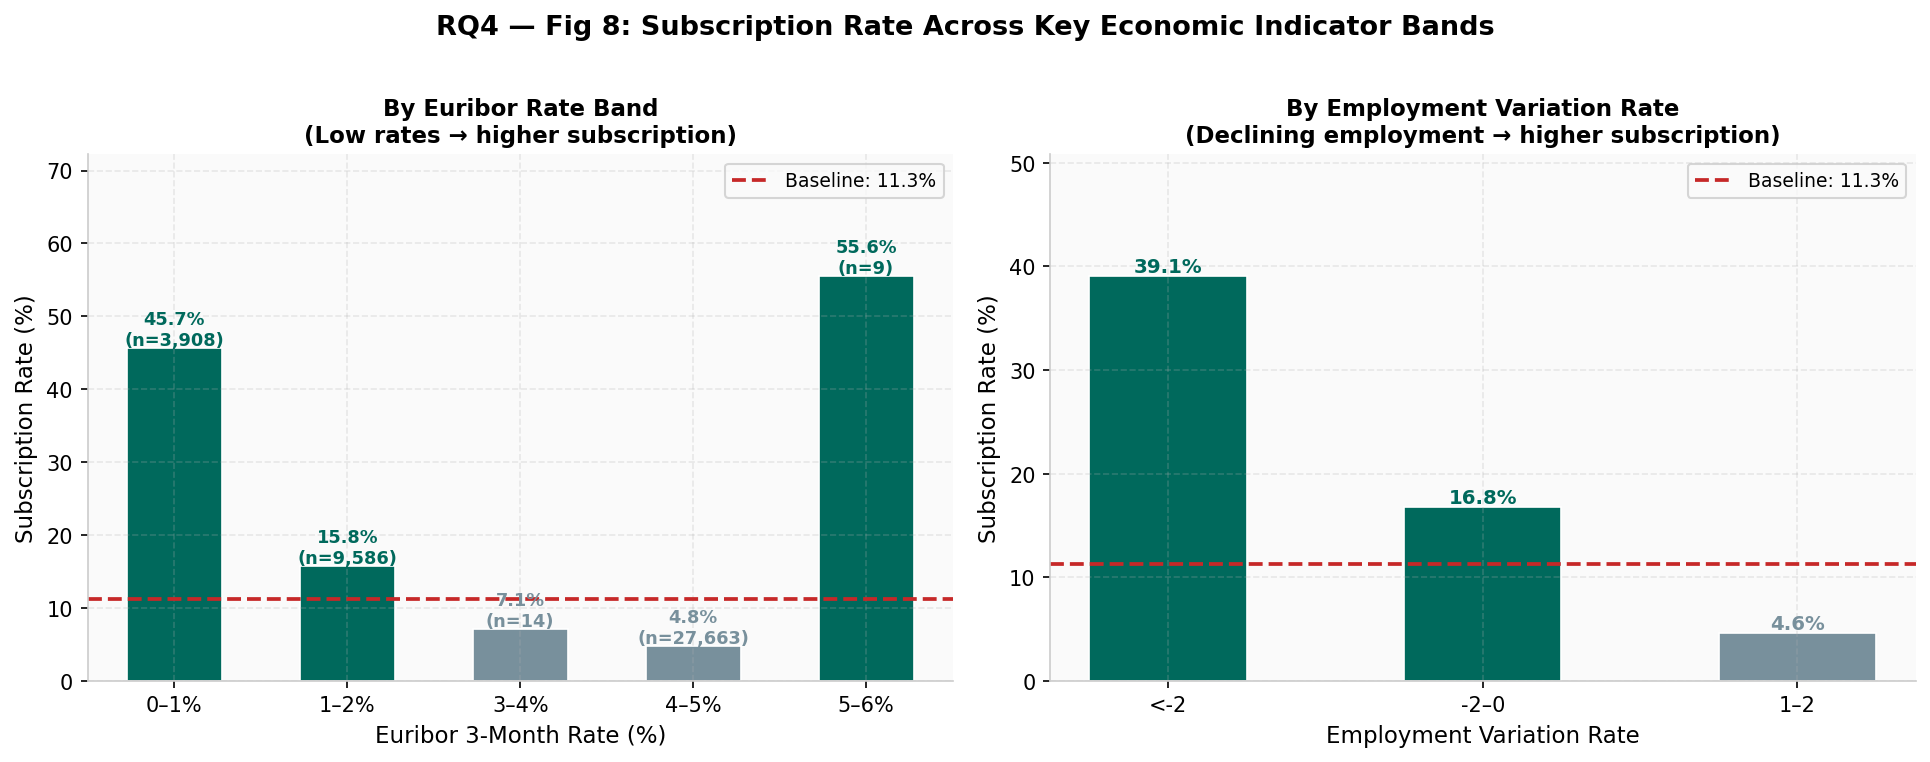

In [28]:
# ── Figure 4b: Euribor rate binned vs subscription rate ──────────────────────
# (Euribor is the most statistically distinct economic feature)
df_enc['euribor_bin'] = pd.cut(
    df_enc['euribor3m'],
    bins=[0, 1, 2, 3, 4, 5, 6],
    labels=['0–1%', '1–2%', '2–3%', '3–4%', '4–5%', '5–6%']
)

euribor_rates = (
    df_enc.groupby('euribor_bin', observed=True)['subscribed_bin']
          .agg(['mean', 'count'])
)
euribor_rates['rate_%'] = euribor_rates['mean'] * 100

emp_var_rates = (
    df_enc.assign(emp_bin=pd.cut(df_enc['emp.var.rate'],
                                  bins=[-4, -2, 0, 1, 2],
                                  labels=['<-2', '-2–0', '0–1', '1–2']))
          .groupby('emp_bin', observed=True)['subscribed_bin']
          .mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Euribor panel
colors_eur = [TEAL if r > overall_rate else GREY for r in euribor_rates['rate_%']]
bars_eur = axes[0].bar(
    euribor_rates.index.astype(str),
    euribor_rates['rate_%'],
    color=colors_eur, edgecolor='white', linewidth=0.8, width=0.55
)
axes[0].axhline(overall_rate, color=RED, linestyle='--', linewidth=1.8,
                label=f'Baseline: {overall_rate:.1f}%')
for bar, (_, row) in zip(bars_eur, euribor_rates.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, row['rate_%'] + 0.4,
                 f"{row['rate_%']:.1f}%\n(n={int(row['count']):,})",
                 ha='center', fontsize=8.5, fontweight='bold',
                 color=TEAL if row['rate_%'] > overall_rate else GREY)
axes[0].set_xlabel('Euribor 3-Month Rate (%)')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].set_title('By Euribor Rate Band\n(Low rates → higher subscription)',
                  fontweight='bold', fontsize=11)
axes[0].set_ylim(0, euribor_rates['rate_%'].max() * 1.3)
axes[0].legend(fontsize=9)

# Employment variance panel
colors_emp = [TEAL if r > overall_rate else GREY for r in emp_var_rates.values]
bars_emp = axes[1].bar(
    emp_var_rates.index.astype(str),
    emp_var_rates.values,
    color=colors_emp, edgecolor='white', linewidth=0.8, width=0.5
)
axes[1].axhline(overall_rate, color=RED, linestyle='--', linewidth=1.8,
                label=f'Baseline: {overall_rate:.1f}%')
for bar, val in zip(bars_emp, emp_var_rates.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=9.5, fontweight='bold',
                 color=TEAL if val > overall_rate else GREY)
axes[1].set_xlabel('Employment Variation Rate')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_title('By Employment Variation Rate\n(Declining employment → higher subscription)',
                  fontweight='bold', fontsize=11)
axes[1].set_ylim(0, emp_var_rates.max() * 1.3)
axes[1].legend(fontsize=9)

fig.suptitle('RQ4 — Fig 8: Subscription Rate Across Key Economic Indicator Bands',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('rq4_fig8_economic_bands')
plt.show()

**RQ4 Key Findings:**
- All five economic indicators are statistically significant (Mann-Whitney p < 0.05).
- **Low Euribor rates (0–1%)** yield subscription rates above 30% — customers are more receptive to fixed-term deposits when variable-rate alternatives are unattractive.
- **Declining employment variation** (negative values) correlates with higher subscription — economic uncertainty drives demand for safer financial products.
- These features add contextual signal beyond customer demographics; including them in the ML model should improve performance.

---
## 5. Summary of Findings & Modelling Recommendations

| Research Question | Key Finding | Implication |
|---|---|---|
| **RQ1 — Demographics** | Students (31.4%) & retired (25.2%) convert far above the 11.3% baseline | Segment campaigns toward these groups |
| **RQ2 — Contact Strategy** | March/Sep/Oct are peak months; conversion collapses after 2 contacts | Cap outreach at 2 attempts; avoid May saturation |
| **RQ3 — Prior History** | Prior success → 65.1% conversion (5.7× baseline) | Re-contact prior-success customers first |
| **RQ4 — Economics** | Low Euribor & declining employment lift conversion significantly | Time campaign launches to macro-economic windows |

**Pre-modelling data flags:**
- **Exclude** `duration` — it is recorded after the call and would cause data leakage.
- **Binary-encode** `pdays` → `previously_contacted` flag before fitting.
- **Address class imbalance** (88.7% / 11.3%) using SMOTE or class weighting.
- **Log-transform or cap** `campaign` contacts (11.6% IQR outliers).

print('✔  Notebook complete. All figures saved.')